In [1]:
# Chakraborti et al. 2013
from equipartition import Equipartition
import numpy as np
import scipy
import astropy
import scipy
from astropy.cosmology import FlatLambdaCDM
import matplotlib.pyplot as plt

In [2]:
N = 1000
# a_trunc = 0
# b_trunc = np.inf
# a, b = (a_trunc - loc) / scale, (b_trunc - loc) / scale

# SN 2011ja
Fmjy = scipy.stats.truncnorm.rvs(-0.829/0.033, np.inf, 0.829, 0.033, N)
nup10 = scipy.stats.truncnorm.rvs(-9.29/0.39, np.inf, 9.29/10, 0.39/10, N)
tdays = scipy.stats.truncnorm.rvs(-7/1, np.inf, 7, 1, N)
smallDist = scipy.stats.truncnorm.rvs(-1.0368e+25/2.7771e+23, np.inf, 1.0368e+25, 2.7771e+23, N)
p = 3
epse = 0.1
epsB = 0.1

eq = Equipartition(Fmjy, nup10, tdays, 0, 0, p = p, smallDist = smallDist, newtonian = True, corr = True,\
              hotprotons = True, numelectrons = True, outofequipartition = True, energysum = True,\
              epse = epse, epsB = epsB, fA = 1, fV = 0.36, fOmega = 4)

In [3]:
print("SN 2011ja equipartition analysis with corrections")
print("newtonian equipartition E = {:.3e}±{:.3e}".format(np.mean(eq.energyeq()), np.std(eq.energyeq())))
print("newtonian equipartition R = {:.3e}±{:.3e}".format(np.mean(eq.Req()), np.std(eq.Req())))
print("newtonian equipartition B = {:.3e}±{:.3e}".format(np.mean(eq.magField()), np.std(eq.magField())))
print("newtonian equipartition n = {:.3e}±{:.3e}".format(np.mean(eq.CNMnumDens()), np.std(eq.CNMnumDens())))
print("newtonian equipartition Ne= {:.3e}±{:.3e}".format(np.mean(eq.Ne()), np.std(eq.Ne())))
print("newtonian          betaeqN= {:.3e}±{:.3e}".format(np.mean(eq.betaeqN()), np.std(eq.betaeqN())))
print("newtonian equipartition gM= {:.3e}±{:.3e}".format(np.mean(eq.gammaM()), np.std(eq.gammaM())))

SN 2011ja equipartition analysis with corrections
newtonian equipartition E = 1.780e+44±1.574e+43
newtonian equipartition R = 4.768e+14±2.443e+13
newtonian equipartition B = 1.911e+00±7.955e-02
newtonian equipartition n = 2.351e+04±1.956e+03
newtonian equipartition Ne= 1.064e+49±9.409e+47
newtonian          betaeqN= 2.705e-02±4.542e-03
newtonian equipartition gM= 2.000e+00±0.000e+00


In [4]:
# Bright et al. 2025 EP240414a
COSMO = FlatLambdaCDM(
    H0=70,      # km/s/Mpc
    Om0=0.3,    # matter density parameter
    Tcmb0=2.725 # CMB temperature in K
)
Fmjy = scipy.stats.truncnorm.rvs(-0.434/0.021, np.inf, 0.434, 0.021, N); Fmjy_scalar = 0.434
nup10 = 3/10
tdays = 30
z = scipy.stats.truncnorm.rvs(-0.4018/0.0010, np.inf, 0.4018, 0.0010, N); z_scalar = 0.4018
p = scipy.stats.truncnorm.rvs((2-2.16)/0.3, (3-2.16)/0.3, 2.16, 0.3, N); p_scalar = 2.16
epse = 0.1 # 0.1
epsB = 0.001 # 0.3

eq = Equipartition(Fmjy, nup10, tdays, z, 0, p = p, newtonian = True, BDfactor = True,\
              hotprotons = False, numelectrons = False, outofequipartition = False, energysum = True,\
              epse = epse, fA = 1, fV = 1, fOmega = 1, cosmo = COSMO) # fV usually should be 1 and fOmega usually should be 4 for the Newtonian case

In [5]:
print("EP240414a equipartition analysis Newtonian without corrections (weird geometry + unphysical)") # BDfactor = True reproduces Bright et al.
print("newtonian equipartition E = {:.3e}±{:.3e}".format(np.mean(eq.energyeq()), np.std(eq.energyeq())))
print("newtonian equipartition R = {:.3e}±{:.3e}".format(np.mean(eq.Req()), np.std(eq.Req())))
print("newtonian equipartition B = {:.3e}±{:.3e}".format(np.mean(eq.magField()), np.std(eq.magField())))
print("newtonian equipartition n = {:.3e}±{:.3e}".format(np.mean(eq.CNMnumDens()), np.std(eq.CNMnumDens())))
print("newtonian equipartition Ne= {:.3e}±{:.3e}".format(np.mean(eq.Ne()), np.std(eq.Ne())))
print("newtonian          betaeqN= {:.3e}±{:.3e}".format(np.mean(eq.betaeqN()), np.std(eq.betaeqN())))
print("newtonian equipartition gM= {:.3e}±{:.3e}".format(np.mean(eq.gammaM()), np.std(eq.gammaM())))
print("          equipartition ge= {:.3e}±{:.3e}".format(np.mean(eq.gammae()), np.std(eq.gammae())))

EP240414a equipartition analysis Newtonian without corrections (weird geometry + unphysical)
newtonian equipartition E = 1.463e+49±8.375e+47
newtonian equipartition R = 1.774e+17±4.072e+15
newtonian equipartition B = 8.600e-02±4.928e-04
newtonian equipartition n = 1.489e+01±2.138e-01
newtonian equipartition Ne= 8.702e+52±4.733e+51
newtonian          betaeqN= 3.199e+00±7.376e-02
newtonian equipartition gM= 1.155e+02±6.297e+01
          equipartition ge= 1.311e+02±3.791e-01


C:\Users\rohdo\OneDrive\Desktop\Python\equipartition\equipartition\equipartition.py:186: UserWarning: estimated gammae (at peak) is smaller than estimated gammaM for nu_a > nu_m. Setting kappa = 1 in this case
  warnings.warn("estimated gammae (at peak) is smaller than estimated gammaM for nu_a > nu_m. Setting kappa = 1 in this case")


In [6]:
eq = Equipartition(Fmjy, nup10, tdays, z, 0, p = p, newtonian = False, onAxis = True,\
              hotprotons = False, numelectrons = False, outofequipartition = False, energysum = True,\
              epse = epse, fA = 1, fV = 1, fOmega = 1, cosmo = COSMO)

In [7]:
print("EP240414a equipartition analysis relativistic without corrections")
print("          equipartition E = {:.3e}±{:.3e}".format(np.mean(eq.energyeq()), np.std(eq.energyeq())))
print("          equipartition R = {:.3e}±{:.3e}".format(np.mean(eq.Req()), np.std(eq.Req())))
print("          equipartition B = {:.3e}±{:.3e}".format(np.mean(eq.magField()), np.std(eq.magField())))
print("          equipartition n = {:.3e}±{:.3e}".format(np.mean(eq.CNMnumDens()), np.std(eq.CNMnumDens())))
print("          equipartition Ne= {:.3e}±{:.3e}".format(np.mean(eq.Ne()), np.std(eq.Ne())))
print("                 gammaBulk= {:.3e}±{:.3e}".format(np.mean(eq.gammaBulk()), np.std(eq.gammaBulk())))
print("newtonian          betaeqN= {:.3e}±{:.3e}".format(np.mean(eq.betaeqN()), np.std(eq.betaeqN())))
print("          equipartition gM= {:.3e}±{:.3e}".format(np.mean(eq.gammaM()), np.std(eq.gammaM())))
print("          equipartition ge= {:.3e}±{:.3e}".format(np.mean(eq.gammae()), np.std(eq.gammae())))
print("                     curlc= {:.3e}±{:.3e}".format(np.mean(eq.C()), np.std(eq.C())))

EP240414a equipartition analysis relativistic without corrections
          equipartition E = 1.819e+48±7.226e+46
          equipartition R = 2.026e+17±1.275e+16
          equipartition B = 4.028e-02±2.305e-03
          equipartition n = 2.368e+00±3.499e-01
          equipartition Ne= 7.780e+51±2.518e+50
                 gammaBulk= 1.614e+00±3.496e-02
newtonian          betaeqN= 3.498e+00±1.835e-01
          equipartition gM= 2.538e+01±1.478e+01
          equipartition ge= 1.130e+02±1.802e+00
                     curlc= 3.741e+00±4.423e-01


In [8]:
eq = Equipartition(Fmjy, nup10, tdays, z, 0, p = p, newtonian = False, onAxis = True,\
              hotprotons = True, numelectrons = True, outofequipartition = False, energysum = True,\
              epse = epse, epsB = None, fA = 1, fV = 1, fOmega = 1, cosmo = COSMO)

In [9]:
print("EP240414a equipartition analysis relativistic with corrections but still in equipartition")
print("          equipartition E = {:.3e}±{:.3e}".format(np.mean(eq.energyeq()), np.std(eq.energyeq())))
print("          equipartition R = {:.3e}±{:.3e}".format(np.mean(eq.Req()), np.std(eq.Req())))
print("          equipartition B = {:.3e}±{:.3e}".format(np.mean(eq.magField()), np.std(eq.magField())))
print("          equipartition n = {:.3e}±{:.3e}".format(np.mean(eq.CNMnumDens()), np.std(eq.CNMnumDens())))
print("          equipartition Ne= {:.3e}±{:.3e}".format(np.mean(eq.Ne()), np.std(eq.Ne())))
print("                 gammaBulk= {:.3e}±{:.3e}".format(np.mean(eq.gammaBulk()), np.std(eq.gammaBulk())))
print("newtonian          betaeqN= {:.3e}±{:.3e}".format(np.mean(eq.betaeqN()), np.std(eq.betaeqN())))
print("          equipartition gM= {:.3e}±{:.3e}".format(np.mean(eq.gammaM()), np.std(eq.gammaM())))
print("          equipartition ge= {:.3e}±{:.3e}".format(np.mean(eq.gammae()), np.std(eq.gammae())))
print("                       nuc= {:.3e}±{:.3e}".format(np.mean(eq.nuc()), np.std(eq.nuc())))

EP240414a equipartition analysis relativistic with corrections but still in equipartition
          equipartition E = 6.290e+48±3.381e+47
          equipartition R = 2.368e+17±1.644e+16
          equipartition B = 6.452e-02±2.699e-03
          equipartition n = 7.542e+00±1.146e+01
          equipartition Ne= 3.120e+52±4.208e+52
                 gammaBulk= 1.706e+00±4.284e-02
newtonian          betaeqN= 3.996e+00±2.365e-01
          equipartition gM= 2.923e+01±1.710e+01
          equipartition ge= 8.620e+01±7.640e-01
                       nuc= 1.394e+15±1.658e+14


In [10]:
print("EP240414a equipartition analysis relativistic with corrections but still in equipartition logs")
print("          equipartition E = {:.2f}±{:.2f}".format(np.mean(np.log10(eq.energyeq())), np.std(np.log10(eq.energyeq()))))
print("          equipartition R = {:.2f}±{:.2f}".format(np.mean(np.log10(eq.Req())), np.std(np.log10(eq.Req()))))
print("          equipartition B = {:.2f}±{:.2f}".format(np.mean(np.log10(eq.magField())), np.std(np.log10(eq.magField()))))
print("          equipartition n = {:.2f}±{:.2f}".format(np.mean(np.log10(eq.CNMnumDens())), np.std(np.log10(eq.CNMnumDens()))))
print("          equipartition Ne= {:.2f}±{:.2f}".format(np.mean(np.log10(eq.Ne())), np.std(np.log10(eq.Ne()))))
print("                 gammaBulk= {:.2f}±{:.2f}".format(np.mean(np.log10(eq.gammaBulk())), np.std(np.log10(eq.gammaBulk()))))
print("newtonian          betaeqN= {:.2f}±{:.2f}".format(np.mean(np.log10(eq.betaeqN())), np.std(np.log10(eq.betaeqN()))))
print("          equipartition gM= {:.2f}±{:.2f}".format(np.mean(np.log10(eq.gammaM())), np.std(np.log10(eq.gammaM()))))
print("          equipartition ge= {:.2f}±{:.2f}".format(np.mean(np.log10(eq.gammae())), np.std(np.log10(eq.gammae()))))
print("                       nuc= {:.2f}±{:.2f}".format(np.mean(np.log10(eq.nuc())), np.std(np.log10(eq.nuc()))))

EP240414a equipartition analysis relativistic with corrections but still in equipartition logs
          equipartition E = 48.80±0.02
          equipartition R = 17.37±0.03
          equipartition B = -1.19±0.02
          equipartition n = 0.62±0.42
          equipartition Ne= 52.30±0.36
                 gammaBulk= 0.23±0.01
newtonian          betaeqN= 0.60±0.03
          equipartition gM= 1.35±0.37
          equipartition ge= 1.94±0.00
                       nuc= 15.14±0.05


In [11]:
eq = Equipartition(Fmjy, nup10, tdays, z, 0, p = p, newtonian = False, onAxis = True, corr = True,\
              hotprotons = True, numelectrons = True, outofequipartition = True, energysum = True,\
              epse = epse, epsB = epsB, fA = 1, fV = 1, fOmega = 1, cosmo = COSMO)

In [12]:
print("EP240414a equipartition analysis relativistic with corrections and out of equipartition") # technically out of equipartition
print("          equipartition E = {:.3e}±{:.3e}".format(np.mean(eq.energyeq()), np.std(eq.energyeq())))
print("          equipartition R = {:.3e}±{:.3e}".format(np.mean(eq.Req()), np.std(eq.Req())))
print("          equipartition B = {:.3e}±{:.3e}".format(np.mean(eq.magField()), np.std(eq.magField())))
print("          equipartition n = {:.3e}±{:.3e}".format(np.mean(eq.CNMnumDens()), np.std(eq.CNMnumDens())))
print("          equipartition Ne= {:.3e}±{:.3e}".format(np.mean(eq.Ne()), np.std(eq.Ne())))
print("                  gammBulk= {:.3e}±{:.3e}".format(np.mean(eq.gammaBulk()), np.std(eq.gammaBulk())))
print("newtonian          betaeqN= {:.3e}±{:.3e}".format(np.mean(eq.betaeqN()), np.std(eq.betaeqN())))
print("          equipartition gM= {:.3e}±{:.3e}".format(np.mean(eq.gammaM()), np.std(eq.gammaM())))
print("          equipartition ge= {:.3e}±{:.3e}".format(np.mean(eq.gammae()), np.std(eq.gammae())))
print("                       nuc= {:.3e}±{:.3e}".format(np.mean(eq.nuc()), np.std(eq.nuc())))

EP240414a equipartition analysis relativistic with corrections and out of equipartition
          equipartition E = 8.583e+49±1.491e+49
          equipartition R = 1.600e+17±1.238e+16
          equipartition B = 1.926e-02±3.720e-04
          equipartition n = 3.428e+02±4.051e+02
          equipartition Ne= 5.718e+53±5.667e+53
                  gammBulk= 1.493e+00±3.644e-02
newtonian          betaeqN= 2.873e+00±1.962e-01
          equipartition gM= 2.059e+01±1.223e+01
          equipartition ge= 1.719e+02±2.930e+00
                       nuc= 5.728e+16±3.275e+15


In [13]:
print("EP240414a equipartition analysis relativistic with corrections and out of equipartition logs")
print("          equipartition E = {:.2f}±{:.2f}".format(np.mean(np.log10(eq.energyeq())), np.std(np.log10(eq.energyeq()))))
print("          equipartition R = {:.2f}±{:.2f}".format(np.mean(np.log10(eq.Req())), np.std(np.log10(eq.Req()))))
print("          equipartition B = {:.2f}±{:.2f}".format(np.mean(np.log10(eq.magField())), np.std(np.log10(eq.magField()))))
print("          equipartition n = {:.2f}±{:.2f}".format(np.mean(np.log10(eq.CNMnumDens())), np.std(np.log10(eq.CNMnumDens()))))
print("          equipartition Ne= {:.2f}±{:.2f}".format(np.mean(np.log10(eq.Ne())), np.std(np.log10(eq.Ne()))))
print("                 gammaBulk= {:.2f}±{:.2f}".format(np.mean(np.log10(eq.gammaBulk())), np.std(np.log10(eq.gammaBulk()))))
print("newtonian          betaeqN= {:.2f}±{:.2f}".format(np.mean(np.log10(eq.betaeqN())), np.std(np.log10(eq.betaeqN()))))
print("          equipartition gM= {:.2f}±{:.2f}".format(np.mean(np.log10(eq.gammaM())), np.std(np.log10(eq.gammaM()))))
print("          equipartition ge= {:.2f}±{:.2f}".format(np.mean(np.log10(eq.gammae())), np.std(np.log10(eq.gammae()))))
print("                       nuc= {:.2f}±{:.2f}".format(np.mean(np.log10(eq.nuc())), np.std(np.log10(eq.nuc()))))

EP240414a equipartition analysis relativistic with corrections and out of equipartition logs
          equipartition E = 49.93±0.08
          equipartition R = 17.20±0.03
          equipartition B = -1.72±0.01
          equipartition n = 2.35±0.36
          equipartition Ne= 53.63±0.29
                 gammaBulk= 0.17±0.01
newtonian          betaeqN= 0.46±0.03
          equipartition gM= 1.20±0.36
          equipartition ge= 2.24±0.01
                       nuc= 16.76±0.02


In [14]:
tsec = tdays * 86400
st = 6.652e-25 # thomson cross section cgs
gammac = lambda B, G : 6 * np.pi * 9.109e-28 * 2.998e10 / (st * B**2 * G * tsec/(1 + z_scalar))
nuc = lambda B, G, D: D * gammac(B, G)**2 * 4.80320425e-10 * B / (2 * np.pi * 9.109e-28 * 2.998e10 * (1 + z_scalar))

nuc_actual = 1e16 #9e9 requires too large of a nuc than what Bright et al. constrains

func = lambda eB: Equipartition(Fmjy_scalar, nup10, tdays, z_scalar, 0, p = p_scalar, newtonian = False, onAxis = True, corr = True,\
              hotprotons = True, numelectrons = True, outofequipartition = True, energysum = True,\
              epse = epse, epsB = eB, fA = 1, fV = 1, fOmega = 1, cosmo = COSMO)

constraint = lambda eB : nuc(func(eB).magField(), func(eB).gammaBulk(), func(eB).deltaD()) - nuc_actual

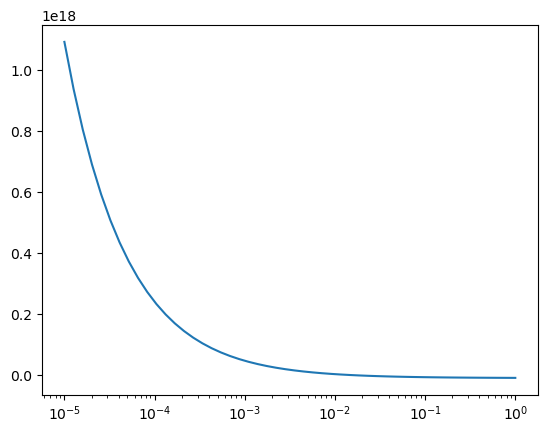

In [15]:
eB = np.geomspace(0.00001, 0.999)
plt.xscale("log")
plt.plot(eB, constraint(eB))

In [16]:
scipy.optimize.brentq(constraint, 1e-12, 1 - 1e-12)

0.01486405266335272

In [17]:
N = 10

Fmjy = scipy.stats.truncnorm.rvs(-0.434/0.021, np.inf, 0.434, 0.021, N); Fmjy_scalar = 0.434
nup10 = 3/10
tdays = 30
z = scipy.stats.truncnorm.rvs(-0.4018/0.0010, np.inf, 0.4018, 0.0010, N); z_scalar = 0.4018
p = scipy.stats.truncnorm.rvs((2-2.16)/0.3, (3-2.16)/0.3, 2.16, 0.3, N); p_scalar = 2.16
epse = 0.1 # 0.1
epsB = 0.001 # 0.3

eBs = np.geomspace(0.0001, 0.999)

eqs = [Equipartition(Fmjy, nup10, tdays, z, 0, p = p, newtonian = False, onAxis = True, corr = True,\
              hotprotons = True, numelectrons = True, outofequipartition = True, energysum = True,\
              epse = epse, epsB = eB, fA = 1, fV = 1, fOmega = 1, cosmo = COSMO) for eB in eBs]

In [18]:
epsBineqs = Equipartition(Fmjy, nup10, tdays, z, 0, p = p, newtonian = False, onAxis = True, corr = True,\
              hotprotons = True, numelectrons = True, outofequipartition = True, energysum = True,\
              epse = epse, epsB = None, fA = 1, fV = 1, fOmega = 1, cosmo = COSMO).epsB
epsBineqmean = np.mean(epsBineqs)
epsBineqstd = np.std(epsBineqs, ddof = 1)

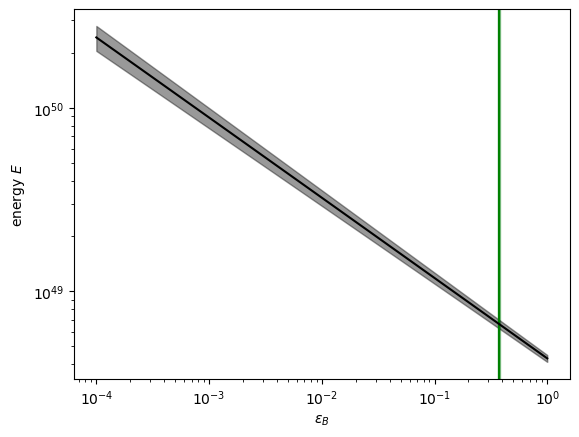

In [19]:
energyeqmean = np.array([np.mean(eq.energyeq()) for eq in eqs])
energyeqstd = np.array([np.std(eq.energyeq(), ddof = 1) for eq in eqs])

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\epsilon_B$")
plt.ylabel(r"energy $E$")
plt.axvline(epsBineqmean)
plt.axvspan(epsBineqmean - epsBineqstd, epsBineqmean + epsBineqstd, color = "g", alpha = 0.4)
plt.axvline(epsBineqmean, color = "g")
plt.fill_between(eBs, energyeqmean - energyeqstd, energyeqmean + energyeqstd, color = "k", alpha = 0.4)
plt.plot(eBs, energyeqmean, color = "k")

In [62]:
# Keim et al. 2019 J0231−0433
N = 5000000
COSMO = FlatLambdaCDM(
    H0=70,
    Om0=0.28,
)

Fmjy = scipy.stats.truncnorm.rvs(-330/60, np.inf, 330, 60, N); Fmjy_scalar = 330 # 0.33 ± 0.06 Jy
nup10 = scipy.stats.truncnorm.rvs(-0.0272/0.0036, np.inf, 0.0272, 0.0036, N); nup10_scalar = 0.0272 # 272 ± 36 MHz
tdays = 1e9 # nonsensical for AGN but gammaM depends on this
z = 0.188
athin = scipy.stats.truncnorm.rvs((-1 - -0.57)/0.16, (-1/2 - -0.57)/0.16, -0.57, 0.16, N) # −0.57 ± 0.16
p = 1 - 2 * athin; p_scalar = 1 - 2 * -0.57
epse = 0.1 # 0.1
#epsB = 0.001

eq = Equipartition(Fmjy, nup10, tdays, z, 0, p = p, newtonian = True,\
              hotprotons = False, numelectrons = False, outofequipartition = False, energysum = True, BDfactor = True,\
              epse = epse, fA = 1, fV = 0.36, fOmega = 4, cosmo = COSMO) # fV usually should be 0.36 and fOmega usually should be 4 for the Newtonian case

In [21]:
print("Keim et al. 2019 J0231−0433 equipartition analysis without corrections (C=3, pbar=2, xi=1, epsilon=1)")
print("newtonian equipartition E = {:.3e}±{:.3e}".format(np.mean(eq.energyeq()), np.std(eq.energyeq())))
print("newtonian equipartition R = {:.3e}±{:.3e}".format(np.mean(eq.Req()), np.std(eq.Req())))
print("newtonian equipartition B = {:.3e}±{:.3e}".format(np.mean(eq.magField()), np.std(eq.magField())))
print("newtonian equipartition n = {:.3e}±{:.3e}".format(np.mean(eq.CNMnumDens()), np.std(eq.CNMnumDens())))
print("newtonian equipartition Ne= {:.3e}±{:.3e}".format(np.mean(eq.Ne()), np.std(eq.Ne())))
# print("newtonian          betaeqN= {:.3e}±{:.3e}".format(np.mean(eq.betaeqN()), np.std(eq.betaeqN())))
# print("newtonian equipartition gM= {:.3e}±{:.3e}".format(np.mean(eq.gammaM()), np.std(eq.gammaM())))

Keim et al. 2019 J0231−0433 equipartition analysis without corrections (C=3, pbar=2, xi=1, epsilon=1)
newtonian equipartition E = 5.264e+52±1.351e+52
newtonian equipartition R = 2.699e+19±4.474e+18
newtonian equipartition B = 4.639e-03±6.232e-04
newtonian equipartition n = 3.328e-03±8.918e-04
newtonian equipartition Ne= 2.617e+56±6.490e+55


In [22]:
eq = Equipartition(Fmjy, nup10, tdays, z, 0, p = p, newtonian = True,\
              hotprotons = True, numelectrons = True, outofequipartition = False, energysum = True, BDfactor = False,\
              epse = epse, fA = 1, fV = 0.36, fOmega = 4, cosmo = COSMO)

In [23]:
print("Keim et al. 2019 J0231−0433 equipartition analysis with corrections (in equipartition)")
print("          equipartition E = {:.3e}±{:.3e}".format(np.mean(eq.energyeq()), np.std(eq.energyeq())))
print("          equipartition R = {:.3e}±{:.3e}".format(np.mean(eq.Req()), np.std(eq.Req())))
print("          equipartition B = {:.3e}±{:.3e}".format(np.mean(eq.magField()), np.std(eq.magField())))
print("          equipartition n = {:.3e}±{:.3e}".format(np.mean(eq.CNMnumDens()), np.std(eq.CNMnumDens())))
print("          equipartition Ne= {:.3e}±{:.3e}".format(np.mean(eq.Ne()), np.std(eq.Ne())))
print("newtonian          betaeqN= {:.3e}±{:.3e}".format(np.mean(eq.betaeqN()), np.std(eq.betaeqN())))
print("          equipartition gM= {:.3e}±{:.3e}".format(np.mean(eq.gammaM()), np.std(eq.gammaM())))
print("          equipartition ge= {:.3e}±{:.3e}".format(np.mean(eq.gammae()), np.std(eq.gammae())))
print("         equipartition nua= {:.3e}±{:.3e}".format(np.mean(eq.nusyn(eq.gammae())), np.std(eq.nusyn(eq.gammae()))))
print("                       nuc= {:.3e}±{:.3e}".format(np.mean(eq.nuc()), np.std(eq.nuc())))

Keim et al. 2019 J0231−0433 equipartition analysis with corrections (in equipartition)
          equipartition E = 5.140e+53±3.950e+53
          equipartition R = 3.565e+19±6.949e+18
          equipartition B = 9.170e-03±1.993e-03
          equipartition n = 1.497e-01±6.223e-02
          equipartition Ne= 3.087e+58±2.364e+58
newtonian          betaeqN= 1.635e-05±3.187e-06
          equipartition gM= 2.000e+00±0.000e+00
          equipartition ge= 1.124e+02±8.901e+00
         equipartition nua= 2.676e+08±3.542e+07
                       nuc= 4.496e+02±3.018e+02


In [31]:
BSSAEW = scipy.stats.truncnorm.rvs(-0.4e-3/0.2236067977e-3, np.inf, 0.4e-3, 0.2236067977e-3, 50000)
epsB = []

for B in BSSAEW:
    eq = lambda eB: Equipartition(Fmjy[:1000], nup10[:1000], 1e12, z, 0, p = p[:1000], newtonian = True,\
                  hotprotons = True, numelectrons = True, outofequipartition = True, energysum = True, BDfactor = False,\
                  epse = epse, epsB = eB, fA = 1, fV = 0.36, fOmega = 4, cosmo = COSMO)
    
    func = lambda eB : np.mean(eq(eB).magField()) - B

    try:
        epsB.append(scipy.optimize.brentq(func, 1e-16, 1 - 1e-16))
    except:
        pass

length:  5000000
epsB 1.4866841461190562e-06 ± 3.038420035058631e-06


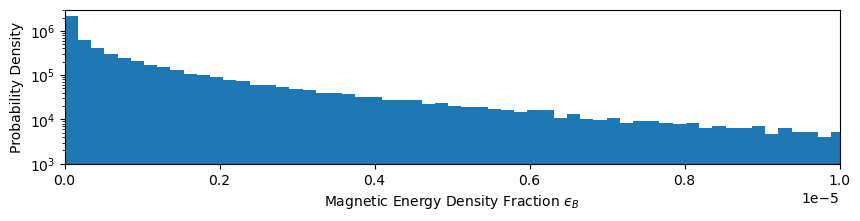

In [67]:
epsB = np.array(epsB)
print("length: ", len(epsB))
plt.figure(figsize = (10, 2))
plt.xlim(0, 1e-5)
plt.xlabel(r"Magnetic Energy Density Fraction $ϵ_B$")
plt.ylim(1e3, 3e6)
plt.yscale("log")
plt.ylabel(r"Probability Density")
plt.hist(epsB, bins = 500, density = True)
print("epsB", np.mean(epsB), "±", np.std(epsB, ddof = 1))
plt.savefig("magenergydensityfractionAGN.svg")

In [59]:
import random

epsB = np.array([random.choice(epsB) for i in range(0, N)])
epsB

array([1.54560898e-06, 1.62898176e-06, 1.79190253e-12, ...,
       2.81469707e-06, 6.57665269e-07, 7.48782177e-07], shape=(5000000,))

In [63]:
eq = Equipartition(Fmjy, nup10, 1e12, z, 0, p = p, newtonian = True,\
              hotprotons = True, numelectrons = True, outofequipartition = True, energysum = True, BDfactor = False,\
              epse = epse, epsB = epsB, fA = 1, fV = 0.36, fOmega = 4, cosmo = COSMO)

In [64]:
print("Keim et al. 2019 J0231−0433 equipartition analysis with corrections (out of equipartition)")
print("          equipartition E = {:.3e}±{:.3e}".format(np.mean(eq.energyeq()), np.std(eq.energyeq())))
print("          equipartition R = {:.3e}±{:.3e}".format(np.mean(eq.Req()), np.std(eq.Req())))
print("          equipartition B = {:.3e}±{:.3e}".format(np.mean(eq.magField()), np.std(eq.magField())))
print("          equipartition n = {:.3e}±{:.3e}".format(np.mean(eq.CNMnumDens()), np.std(eq.CNMnumDens())))
print("          equipartition Ne= {:.3e}±{:.3e}".format(np.mean(eq.Ne()), np.std(eq.Ne())))
print("newtonian          betaeqN= {:.3e}±{:.3e}".format(np.mean(eq.betaeqN()), np.std(eq.betaeqN())))
print("          equipartition gM= {:.3e}±{:.3e}".format(np.mean(eq.gammaM()), np.std(eq.gammaM())))
print("          equipartition ge= {:.3e}±{:.3e}".format(np.mean(eq.gammae()), np.std(eq.gammae())))
print("         equipartition nua= {:.3e}±{:.3e}".format(np.mean(eq.nusyn(eq.gammae())), np.std(eq.nusyn(eq.gammae()))))
print("                       nuc= {:.3e}±{:.3e}".format(np.mean(eq.nuc()), np.std(eq.nuc())))
print("                     curlc= {:.3e}±{:.3e}".format(np.mean(eq.C()), np.std(eq.C())))

Keim et al. 2019 J0231−0433 equipartition analysis with corrections (out of equipartition)
          equipartition E = 3.055e+57±8.155e+58
          equipartition R = 1.596e+19±4.106e+18
          equipartition B = 4.183e-04±2.402e-04
          equipartition n = 2.588e+05±5.330e+06
          equipartition Ne= 1.832e+62±4.884e+63
newtonian          betaeqN= 7.319e-09±1.883e-09
          equipartition gM= 2.000e+00±0.000e+00
          equipartition ge= 6.373e+02±4.887e+02
         equipartition nua= 2.677e+08±3.542e+07
                       nuc= 1.104e+05±2.381e+06
                     curlc= 3.736e+00±4.464e-01


min gammae is 1.196305260421e+02 and max is 1.655183328216e+02


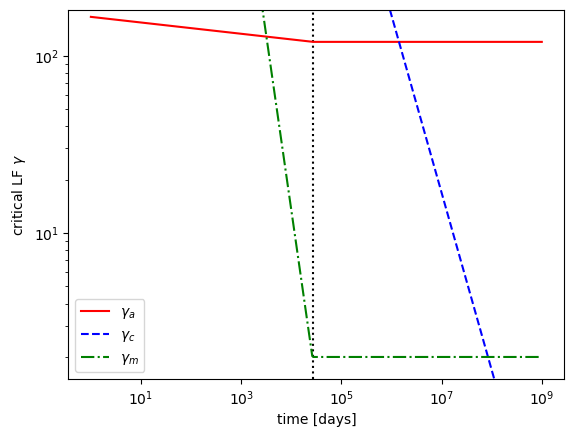

In [29]:
t = np.geomspace(1, 1000000000, 500)
eq = Equipartition(Fmjy_scalar, nup10_scalar, t, z, 0, p = p_scalar, newtonian = True,\
              hotprotons = True, numelectrons = True, outofequipartition = False, energysum = True, BDfactor = False,\
              epse = epse, fA = 1, fV = 0.36, fOmega = 4, cosmo = COSMO)

plt.axvline(t[np.where(eq.gammaM() == 2)[0][0]], color = "k", linestyle = ":")
plt.ylim(1.5, 1.1 * np.max(eq.gammae())) 
plt.ylabel(r"critical LF $\gamma$")
plt.xlabel("time [days]")
plt.loglog(t, eq.gammae(), color = "r", linestyle = "-", label = r"$\gamma_a$")
print("min gammae is {:.12e} and max is {:.12e}".format(np.min(eq.gammae()), np.max(eq.gammae())))
plt.loglog(t, eq.gammac(), color = "b", linestyle = "--", label = r"$\gamma_c$")
plt.loglog(t, eq.gammaM(), color = "g", linestyle = "-.", label = r"$\gamma_m$")
plt.legend()

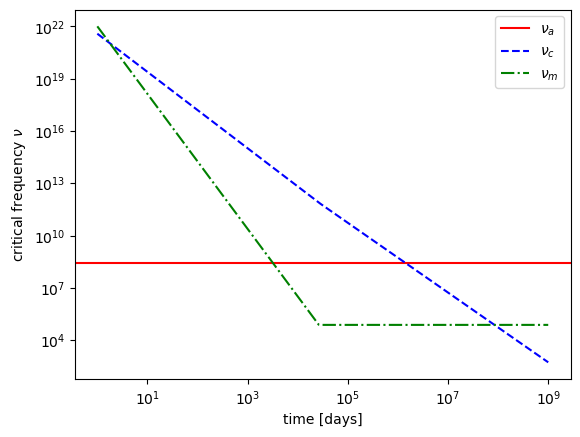

In [30]:
plt.ylabel(r"critical frequency $\nu$")
plt.xlabel("time [days]")
plt.axhline(eq.nup, color = "r", linestyle = "-", label = r"$\nu_a$")
plt.loglog(t, eq.nuc(), color = "b", linestyle = "--", label = r"$\nu_c$")
plt.loglog(t, eq.nusyn(eq.gammaM()), color = "g", linestyle = "-.", label = r"$\nu_m$")
plt.legend()